In [12]:
import os
import numpy as np
import xarray as xr
import rioxarray
import geopandas as gpd
from rasterstats import zonal_stats
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings("ignore")


In [2]:

gdf = gpd.read_file("Mapas/Municipio/MGN_ADM_MPIO_GRAFICO.shp", encoding="utf_8")
gdf = gdf.rename(columns={'mpio_cnmbr': 'municipio'})
gdf = gdf[gdf['dpto_cnmbr'] == 'ATLÁNTICO']

In [6]:
print(gdf.head())

    dpto_ccdgo mpio_ccdgo mpio_cdpmp dpto_cnmbr         municipio  \
125         08        001      08001  ATLÁNTICO      BARRANQUILLA   
126         08        078      08078  ATLÁNTICO           BARANOA   
127         08        137      08137  ATLÁNTICO  CAMPO DE LA CRUZ   
128         08        141      08141  ATLÁNTICO        CANDELARIA   
129         08        296      08296  ATLÁNTICO            GALAPA   

                                            mpio_crslc  mpio_tipo  mpio_narea  \
125  Ordenanza 30 del 5 de Mayo de 1913 Ley 44 del ...  MUNICIPIO  154.285925   
126             Ordenanza 11 del 23 de Octubre de 1856  MUNICIPIO  121.350425   
127               Ordenanza 34 del 16 de Abril de 1914  MUNICIPIO   99.995006   
128                                     Ley 27 de 1860  MUNICIPIO  135.766433   
129                                     Ley 37 de 1873  MUNICIPIO   97.515400   

     mpio_nano  shape_Leng  shape_Area  \
125       2024    0.817698    0.012760   
126       2024

# Precipitación 

C:\Users\TAWTOCA\AppData\Local\Temp\ipykernel_5744\1785067033.py:54: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf["geometry_centroid"] = gdf.geometry.centroid


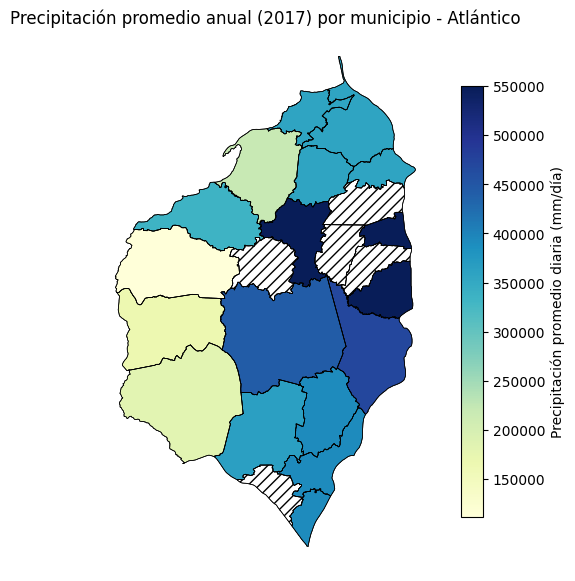

✅ Archivo exportado con latitud, longitud y precipitación promedio por municipio.


In [ ]:
# ------------------------------------------------------------
# 🌧️ Análisis de precipitación promedio anual (2017)
# ------------------------------------------------------------

import os
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from rasterstats import zonal_stats

# ------------------------------------------------------------
# 1️⃣ Cargar datos NetCDF
# ------------------------------------------------------------
ruta = r"C:\Dengue\Datos Clima\precipitacion_atl_2017"
ds = xr.open_mfdataset(os.path.join(ruta, "*.nc"), combine="by_coords")

# Variable principal y CRS
var = ds["Precipitation_Flux"].rio.write_crs("EPSG:4326")

# ------------------------------------------------------------
# 2️⃣ Conversión de unidades (de kg m⁻² s⁻¹ a mm/día)
# ------------------------------------------------------------
# 1 kg m⁻² s⁻¹ = 1 mm/s
# Entonces: mm/día = valor * 86400 (segundos en un día)
var_mm_dia = var * 86400

# Promedio anual (por píxel)
promedio_anual = var_mm_dia.mean(dim="time")

# ------------------------------------------------------------
# 3️⃣ Shapefile del Atlántico
# ------------------------------------------------------------
gdf = gpd.read_file("Mapas/Municipio/MGN_ADM_MPIO_GRAFICO.shp", encoding="utf_8")
gdf = gdf.rename(columns={'mpio_cnmbr': 'municipio'})
gdf = gdf[gdf['dpto_cnmbr'] == 'ATLÁNTICO']

# ------------------------------------------------------------
# 4️⃣ Calcular promedio por municipio
# ------------------------------------------------------------
temp_raster = r"C:\Dengue\Datos Clima\figs\precipitacion_promedio_anual_atl_2017.tif"
promedio_anual.rio.to_raster(temp_raster)

stats = zonal_stats(
    gdf,
    temp_raster,
    stats="mean",
    nodata=np.nan
)

gdf["precipitacion_promedio"] = [s["mean"] for s in stats]

# Coordenadas de centroides
gdf["geometry_centroid"] = gdf.geometry.centroid
gdf["lon"] = gdf["geometry_centroid"].x
gdf["lat"] = gdf["geometry_centroid"].y

# ------------------------------------------------------------
# 5️⃣ Graficar mapa con escala de colores
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8,7))

# Capa base
gdf.boundary.plot(ax=ax, color="black", linewidth=0.5)

# Mapa principal
gdf.plot(
    column="precipitacion_promedio",
    cmap="YlGnBu",
    edgecolor="black",
    linewidth=0.5,
    ax=ax,
    missing_kwds={"color": "white", "edgecolor": "black", "hatch": "///", "label": "Sin datos"}
)

# Crear barra de color personalizada
sm = plt.cm.ScalarMappable(
    cmap="YlGnBu",
    norm=plt.Normalize(vmin=gdf["precipitacion_promedio"].min(), vmax=gdf["precipitacion_promedio"].max())
)
sm._A = []
cbar = fig.colorbar(sm, ax=ax, shrink=0.8)
cbar.set_label("Precipitación promedio diaria (mm/día)")

plt.title("Precipitación promedio anual (2017) por municipio - Atlántico")
plt.axis("off")
plt.show()



Procesando 2017...
Procesando 2018...
Procesando 2019...
Procesando 2020...


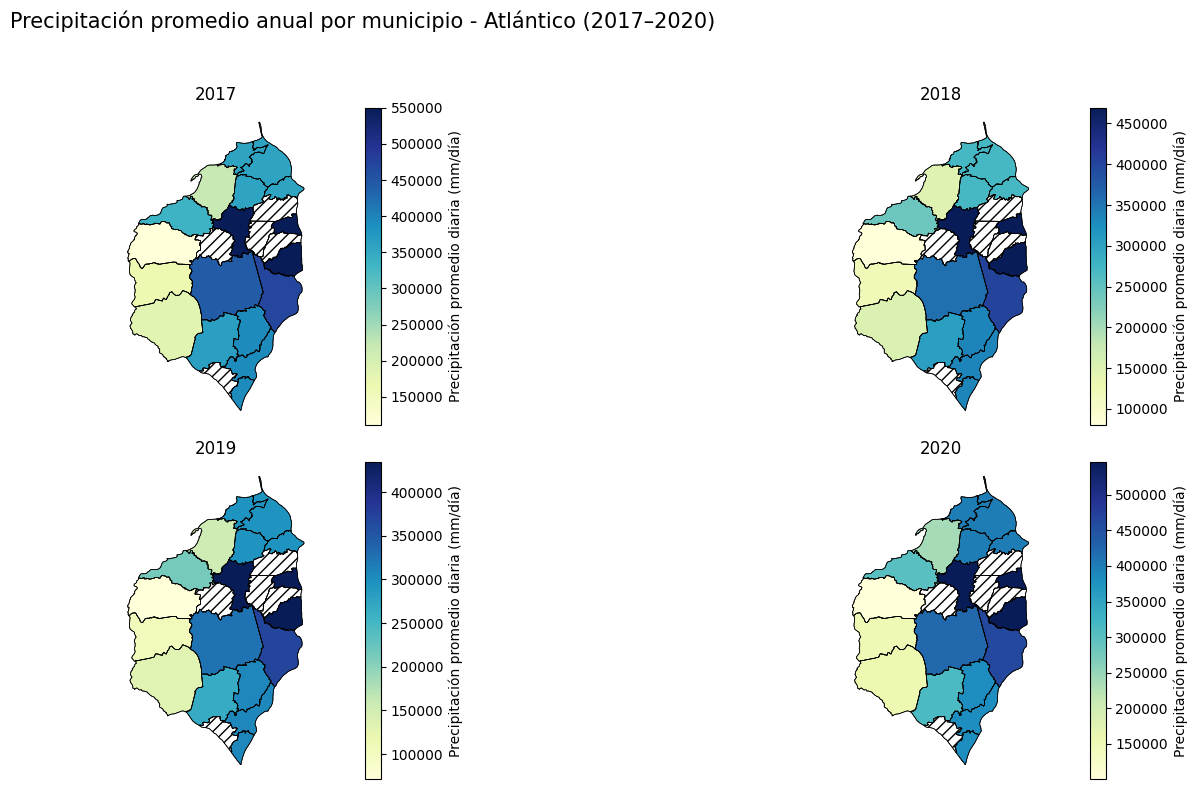

In [8]:
# ------------------------------------------------------------
# 🌧️ Precipitación promedio anual (2017–2020) con escalas individuales
# ------------------------------------------------------------

import os
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from rasterstats import zonal_stats
import rioxarray

# ------------------------------------------------------------
# 1️⃣ Configuración base
# ------------------------------------------------------------
rutas = {
    2017: r"C:\Dengue\Datos Clima\precipitacion_atl_2017",
    2018: r"C:\Dengue\Datos Clima\precipitacion_atl_2018",
    2019: r"C:\Dengue\Datos Clima\precipitacion_atl_2019",
    2020: r"C:\Dengue\Datos Clima\precipitacion_atl_2020"
}

# Shapefile del Atlántico
gdf_base = gpd.read_file("Mapas/Municipio/MGN_ADM_MPIO_GRAFICO.shp", encoding="utf-8")
gdf_base = gdf_base.rename(columns={'mpio_cnmbr': 'municipio'})
gdf_base = gdf_base[gdf_base['dpto_cnmbr'].str.upper() == 'ATLÁNTICO']

# Figura con 4 subplots (2x2)
fig, axes = plt.subplots(2, 2, figsize=(18, 8))
axes = axes.flatten()
cmap = "YlGnBu"

# ------------------------------------------------------------
# 2️⃣ Procesar y graficar cada año con su escala
# ------------------------------------------------------------
for i, (anio, ruta) in enumerate(rutas.items()):
    print(f"Procesando {anio}...")

    # Abrir dataset (todos los archivos del año)
    ds = xr.open_mfdataset(os.path.join(ruta, "*.nc"), combine="by_coords")

    # Variable principal (precipitación)
    var = ds["Precipitation_Flux"].rio.write_crs("EPSG:4326")

    # Convertir unidades a mm/día (si está en kg m⁻² s⁻¹)
    var_mm_dia = var * 86400

    # Promedio anual
    promedio_anual = var_mm_dia.mean(dim="time")

    # Guardar raster temporal
    temp_raster = fr"C:\Dengue\Datos Clima\figs\precipitacion_promedio_anual_{anio}.tif"
    promedio_anual.rio.to_raster(temp_raster)

    # Copiar shapefile
    gdf = gdf_base.copy()

    # Calcular media zonal por municipio
    stats = zonal_stats(gdf, temp_raster, stats="mean", nodata=np.nan)
    gdf["precipitacion_promedio"] = [s["mean"] for s in stats]

    # ------------------------------------------------------------
    # 3️⃣ Graficar cada año con su propia escala
    # ------------------------------------------------------------
    ax = axes[i]
    gdf.boundary.plot(ax=ax, color="black", linewidth=0.5)

    gdf.plot(
        column="precipitacion_promedio",
        cmap=cmap,
        legend=True,
        edgecolor="black",
        linewidth=0.5,
        ax=ax,
        legend_kwds={
            "label": "Precipitación promedio diaria (mm/día)",
            "orientation": "vertical"
        },
        missing_kwds={"color": "white", "edgecolor": "black", "hatch": "///", "label": "Sin datos"}
    )

    ax.set_title(f"{anio}", fontsize=12)
    ax.axis("off")

# ------------------------------------------------------------
# 4️⃣ Ajustes finales
# ------------------------------------------------------------
plt.suptitle("Precipitación promedio anual por municipio - Atlántico (2017–2020)", fontsize=15)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


Procesando 2017...
Procesando 2018...
Procesando 2019...


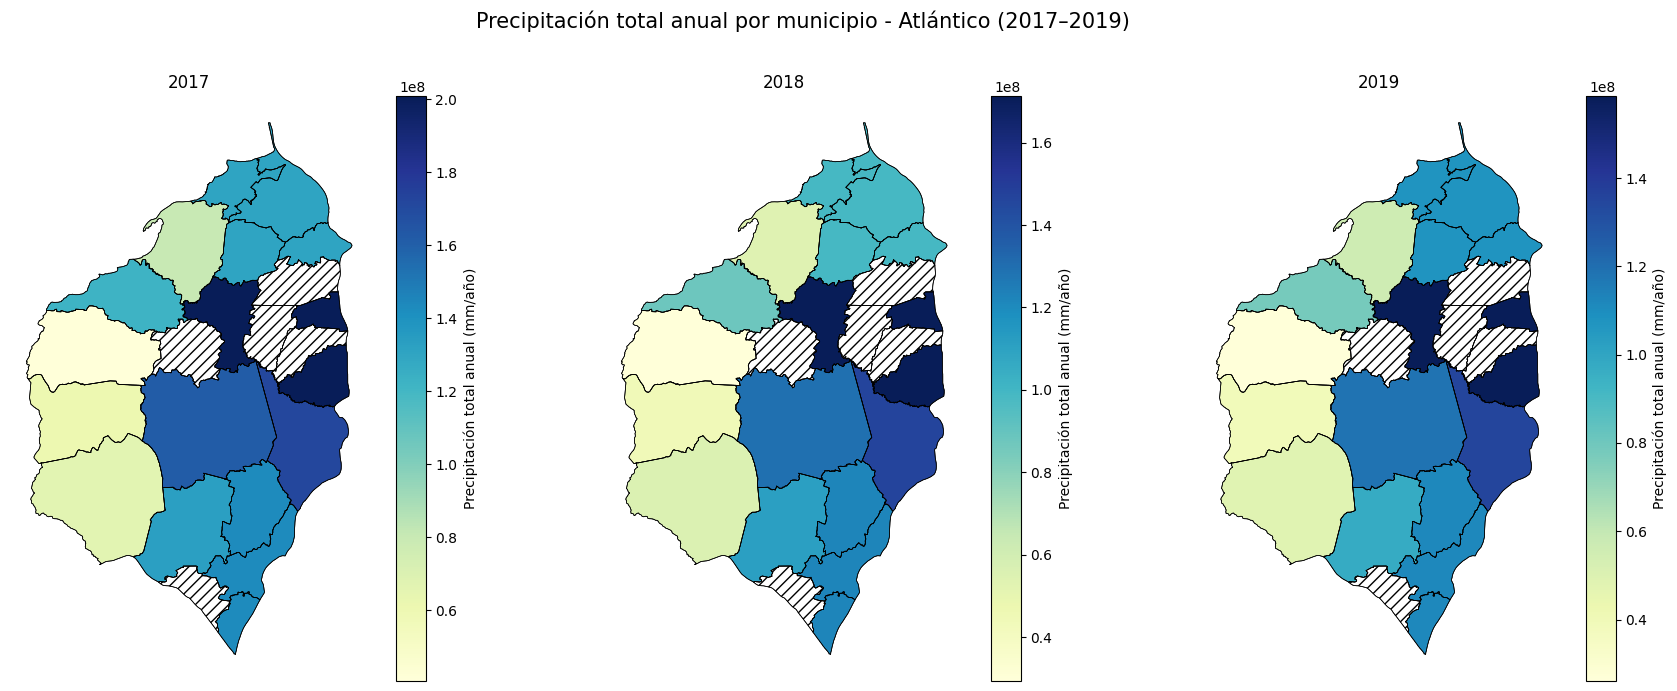

In [ ]:
# ------------------------------------------------------------
# 🌧️ Precipitación total anual (2017–2019) con escalas individuales
# ------------------------------------------------------------

import os
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from rasterstats import zonal_stats

# ------------------------------------------------------------
# 1️⃣ Configuración base
# ------------------------------------------------------------
rutas = {
    2017: r"C:\Dengue\Datos Clima\precipitacion_atl_2017",
    2018: r"C:\Dengue\Datos Clima\precipitacion_atl_2018",
    2019: r"C:\Dengue\Datos Clima\precipitacion_atl_2019"
}

# Shapefile del Atlántico
gdf_base = gpd.read_file("Mapas/Municipio/MGN_ADM_MPIO_GRAFICO.shp", encoding="utf_8")
gdf_base = gdf_base.rename(columns={'mpio_cnmbr': 'municipio'})
gdf_base = gdf_base[gdf_base['dpto_cnmbr'] == 'ATLÁNTICO']

# Figura con 3 subplots (uno por año)
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
cmap = "YlGnBu"

# ------------------------------------------------------------
# 2️⃣ Procesar y graficar cada año con su escala individual
# ------------------------------------------------------------
for i, (anio, ruta) in enumerate(rutas.items()):
    print(f"Procesando {anio}...")

    # Abrir dataset
    ds = xr.open_mfdataset(os.path.join(ruta, "*.nc"), combine="by_coords")

    # Variable principal (precipitación)
    var = ds["Precipitation_Flux"].rio.write_crs("EPSG:4326")

    # Convertir a mm/día y luego a mm/año
    var_mm_dia = var * 86400
    var_mm_anual = var_mm_dia.sum(dim="time")  # suma total anual

    # Guardar raster temporal
    temp_raster = fr"C:\Dengue\Datos Clima\figs\precipitacion_total_anual_{anio}.tif"
    var_mm_anual.rio.to_raster(temp_raster)

    # Copiar shapefile
    gdf = gdf_base.copy()

    # Calcular media zonal
    stats = zonal_stats(gdf, temp_raster, stats="mean", nodata=np.nan)
    gdf["precipitacion_total"] = [s["mean"] for s in stats]

    # ------------------------------------------------------------
    # 3️⃣ Graficar cada año con su propia escala
    # ------------------------------------------------------------
    ax = axes[i]

    # Capa base
    gdf.boundary.plot(ax=ax, color="black", linewidth=0.5)

    # Capa de precipitación con escala individual
    gdf.plot(
        column="precipitacion_total",
        cmap=cmap,
        legend=True,
        edgecolor="black",
        linewidth=0.5,
        ax=ax,
        legend_kwds={
            "label": "Precipitación total anual (mm/año)",
            "orientation": "vertical"
        },
        missing_kwds={"color": "white", "edgecolor": "black", "hatch": "///", "label": "Sin datos"}
    )

    ax.set_title(f"{anio}", fontsize=12)
    ax.axis("off")

plt.suptitle("Precipitación total anual por municipio - Atlántico (2017–2019)", fontsize=15)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


# Humedad

In [3]:
ruta = r"C:\Dengue\Datos Clima\humedad_atl_2017"
archivos = [f for f in os.listdir(ruta) if f.endswith('.nc')]
print(f"Total de archivos: {len(archivos)}")
print(archivos[:5])  # muestra los primeros 5

ds = xr.open_mfdataset(os.path.join(ruta, "*.nc"), combine="by_coords")

print(ds)

print(list(ds.data_vars))

Total de archivos: 365
['Relative-Humidity-2m_06h_C3S-glob-agric_AgERA5_20170101_final-v2.0.0.area-subset.11.3.10.2.-74.5.-75.2.nc', 'Relative-Humidity-2m_06h_C3S-glob-agric_AgERA5_20170102_final-v2.0.0.area-subset.11.3.10.2.-74.5.-75.2.nc', 'Relative-Humidity-2m_06h_C3S-glob-agric_AgERA5_20170103_final-v2.0.0.area-subset.11.3.10.2.-74.5.-75.2.nc', 'Relative-Humidity-2m_06h_C3S-glob-agric_AgERA5_20170104_final-v2.0.0.area-subset.11.3.10.2.-74.5.-75.2.nc', 'Relative-Humidity-2m_06h_C3S-glob-agric_AgERA5_20170105_final-v2.0.0.area-subset.11.3.10.2.-74.5.-75.2.nc']
<xarray.Dataset> Size: 1GB
Dimensions:                   (time: 365, lat: 858, lon: 854)
Coordinates:
  * time                      (time) datetime64[ns] 3kB 2017-01-01 ... 2017-1...
  * lat                       (lat) float64 7kB 11.2 11.1 11.0 ... -74.4 -74.5
  * lon                       (lon) float64 7kB -75.1 -75.0 -74.9 ... 10.1 10.2
Data variables:
    Relative_Humidity_2m_06h  (time, lat, lon) float32 1GB dask.array<chu

C:\Users\TAWTOCA\AppData\Local\Temp\ipykernel_5744\1628820041.py:38: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf["geometry_centroid"] = gdf.geometry.centroid
C:\Users\TAWTOCA\AppData\Local\Temp\ipykernel_5744\1628820041.py:69: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend(title="Humedad relativa promedio (%)", loc="lower left")
C:\Users\TAWTOCA\AppData\Local\Temp\ipykernel_5744\1628820041.py:69: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Humedad relativa promedio (%)", loc="lower left")


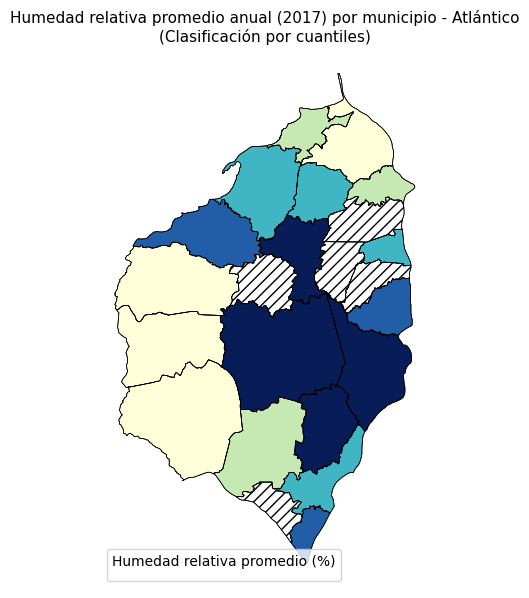

In [ ]:

import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from rasterstats import zonal_stats
import mapclassify # ✅ nuevo: para clasificar los valores


var = ds["Relative_Humidity_2m_06h"].rio.write_crs("EPSG:4326")


promedio_anual = var.mean(dim="time")



gdf = gpd.read_file("Mapas/Municipio/MGN_ADM_MPIO_GRAFICO.shp", encoding="utf_8")


gdf = gdf.rename(columns={'mpio_cnmbr': 'municipio'})
gdf = gdf[gdf['dpto_cnmbr'] == 'ATLÁNTICO']


temp_raster = r"C:\Dengue\Datos Clima\figs\humedad_promedio_anual_atl_2017.tif"
promedio_anual.rio.to_raster(temp_raster)



stats = zonal_stats(
gdf,
temp_raster,
stats="mean",
nodata=np.nan
)


gdf["humedad_promedio"] = [s["mean"] for s in stats]


gdf["geometry_centroid"] = gdf.geometry.centroid
gdf["lon"] = gdf["geometry_centroid"].x
gdf["lat"] = gdf["geometry_centroid"].y



fig, ax = plt.subplots(figsize=(8,7))


gdf.boundary.plot(ax=ax, color="black", linewidth=0.5)

gdf.plot(column="humedad_promedio",
cmap="YlGnBu", # Colores suaves pero contrastantes
legend=True,
scheme="Quantiles", # Clasificación por cuantiles
k=5, # Número de clases
edgecolor="black",
linewidth=0.5,
ax=ax,
missing_kwds={
"color": "white",
"edgecolor": "black",
"hatch": "///",
"label": "Sin datos"
})

plt.title("Humedad relativa promedio anual (2017) por municipio - Atlántico\n(Clasificación por cuantiles)", fontsize=11)
plt.axis("off")



plt.legend(title="Humedad relativa promedio (%)", loc="lower left")

plt.show()

Procesando 2017...
Procesando 2018...
Procesando 2019...
Procesando 2020...


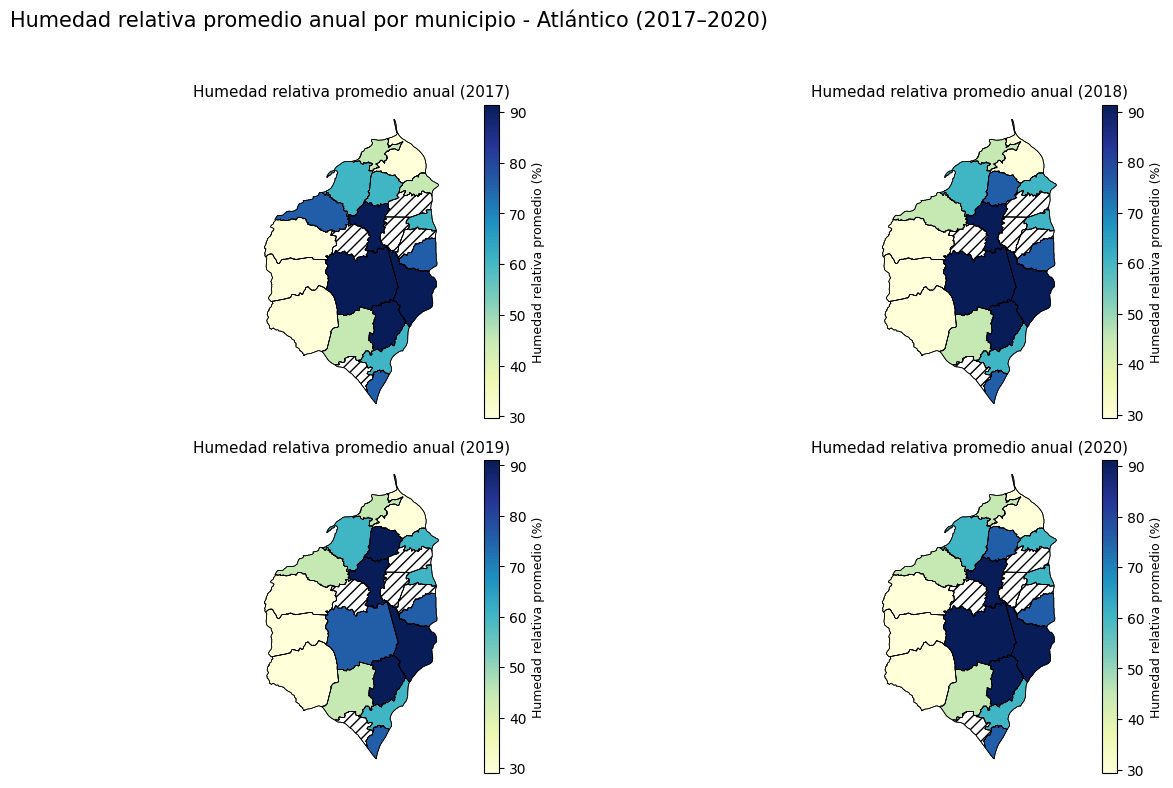

In [13]:
# ------------------------------------------------------------
# 💧 Humedad relativa promedio anual (2017–2020) - Atlántico
# Con escalas individuales (colorbars)
# ------------------------------------------------------------

import os
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from rasterstats import zonal_stats
import mapclassify
import rioxarray

# ------------------------------------------------------------
# 1️⃣ Directorios por año
# ------------------------------------------------------------
rutas = {
    2017: r"C:\Dengue\Datos Clima\humedad_atl_2017",
    2018: r"C:\Dengue\Datos Clima\humedad_atl_2018",
    2019: r"C:\Dengue\Datos Clima\humedad_atl_2019",
    2020: r"C:\Dengue\Datos Clima\humedad_atl_2020"
}

# ------------------------------------------------------------
# 2️⃣ Cargar shapefile del Atlántico
# ------------------------------------------------------------
gdf_base = gpd.read_file("Mapas/Municipio/MGN_ADM_MPIO_GRAFICO.shp", encoding="utf_8")
gdf_base = gdf_base.rename(columns={'mpio_cnmbr': 'municipio'})
gdf_base = gdf_base[gdf_base['dpto_cnmbr'] == 'ATLÁNTICO']

# ------------------------------------------------------------
# 3️⃣ Figura 2x2
# ------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
axes = axes.flatten()
cmap = "YlGnBu"

# ------------------------------------------------------------
# 4️⃣ Procesar cada año
# ------------------------------------------------------------
for i, (anio, ruta) in enumerate(rutas.items()):
    print(f"Procesando {anio}...")

    # Cargar datos netCDF
    ds = xr.open_mfdataset(os.path.join(ruta, "*.nc"), combine="by_coords")

    # Variable: humedad relativa a 2 m (06h)
    var = ds["Relative_Humidity_2m_06h"].rio.write_crs("EPSG:4326")

    # Promedio anual
    promedio_anual = var.mean(dim="time")

    # Guardar raster temporal
    temp_raster = fr"C:\Dengue\Datos Clima\figs\humedad_promedio_anual_atl_{anio}.tif"
    promedio_anual.rio.to_raster(temp_raster)

    # Copiar shapefile
    gdf = gdf_base.copy()

    # Estadísticos zonales
    stats = zonal_stats(
        gdf,
        temp_raster,
        stats="mean",
        nodata=np.nan
    )
    gdf["humedad_promedio"] = [s["mean"] for s in stats]

    # ------------------------------------------------------------
    # 5️⃣ Graficar
    # ------------------------------------------------------------
    ax = axes[i]

    # Bordes
    gdf.boundary.plot(ax=ax, color="black", linewidth=0.5)

    # Capa principal
    gdf_plot = gdf.plot(
        column="humedad_promedio",
        cmap=cmap,
        scheme="Quantiles",
        k=5,
        edgecolor="black",
        linewidth=0.5,
        ax=ax,
        missing_kwds={
            "color": "white",
            "edgecolor": "black",
            "hatch": "///",
            "label": "Sin datos"
        }
    )

    # Escala de colores individual
    sm = plt.cm.ScalarMappable(
        cmap=cmap,
        norm=plt.Normalize(
            vmin=gdf["humedad_promedio"].min(),
            vmax=gdf["humedad_promedio"].max()
        )
    )
    sm._A = []
    cbar = fig.colorbar(sm, ax=ax, orientation="vertical", fraction=0.036, pad=0.04)
    cbar.set_label("Humedad relativa promedio (%)", fontsize=9)

    # Título y estilo
    ax.set_title(f"Humedad relativa promedio anual ({anio})", fontsize=11)
    ax.axis("off")

# ------------------------------------------------------------
# 6️⃣ Ajustes finales
# ------------------------------------------------------------
plt.suptitle("Humedad relativa promedio anual por municipio - Atlántico (2017–2020)",
             fontsize=15)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()



# Temperatura

## Maxima

In [12]:
ruta = r"C:\Dengue\Datos Clima\temp_max_atl_2017"
archivos = [f for f in os.listdir(ruta) if f.endswith('.nc')]
print(f"Total de archivos: {len(archivos)}")
print(archivos[:5])  # muestra los primeros 5

dsm = xr.open_mfdataset(os.path.join(ruta, "*.nc"), combine="by_coords")

print(dsm)

print(list(dsm.data_vars))

Total de archivos: 365
['Temperature-Air-2m_Max-24h_C3S-glob-agric_AgERA5_20170101_final-v2.0.0.area-subset.11.3.-74.5.10.2.-75.2.nc', 'Temperature-Air-2m_Max-24h_C3S-glob-agric_AgERA5_20170102_final-v2.0.0.area-subset.11.3.-74.5.10.2.-75.2.nc', 'Temperature-Air-2m_Max-24h_C3S-glob-agric_AgERA5_20170103_final-v2.0.0.area-subset.11.3.-74.5.10.2.-75.2.nc', 'Temperature-Air-2m_Max-24h_C3S-glob-agric_AgERA5_20170104_final-v2.0.0.area-subset.11.3.-74.5.10.2.-75.2.nc', 'Temperature-Air-2m_Max-24h_C3S-glob-agric_AgERA5_20170105_final-v2.0.0.area-subset.11.3.-74.5.10.2.-75.2.nc']
<xarray.Dataset> Size: 118kB
Dimensions:                     (time: 365, lat: 11, lon: 7)
Coordinates:
  * time                        (time) datetime64[ns] 3kB 2017-01-01 ... 2017...
  * lat                         (lat) float64 88B 11.2 11.1 11.0 ... 10.3 10.2
  * lon                         (lon) float64 56B -75.1 -75.0 ... -74.6 -74.5
Data variables:
    Temperature_Air_2m_Max_24h  (time, lat, lon) float32 112kB d

C:\Users\TAWTOCA\AppData\Local\Temp\ipykernel_5744\3299108173.py:44: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf["geometry_centroid"] = gdf.geometry.centroid


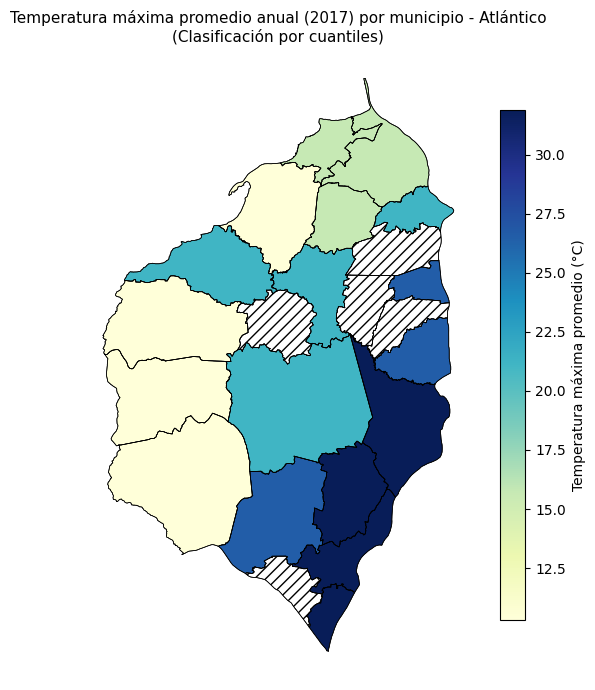

In [ ]:
# ------------------------------------------------------------
# 🌡️ Temperatura Máxima Promedio Anual (2017) - Atlántico
# ------------------------------------------------------------
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from rasterstats import zonal_stats
import mapclassify

# ------------------------------------------------------------
# 1️⃣ Variable principal
# ------------------------------------------------------------
# Convertir de Kelvin a °C si aplica
var = dsm["Temperature_Air_2m_Max_24h"].rio.write_crs("EPSG:4326") - 273.15

# Promedio anual (por píxel)
promedio_anual = var.mean(dim="time")

# ------------------------------------------------------------
# 2️⃣ Shapefile del Atlántico
# ------------------------------------------------------------
gdf = gpd.read_file("Mapas/Municipio/MGN_ADM_MPIO_GRAFICO.shp", encoding="utf_8")
gdf = gdf.rename(columns={'mpio_cnmbr': 'municipio'})
gdf = gdf[gdf['dpto_cnmbr'] == 'ATLÁNTICO']

# ------------------------------------------------------------
# 3️⃣ Guardar raster temporal y calcular promedio por municipio
# ------------------------------------------------------------
temp_raster = r"C:\Dengue\Datos Clima\figs\temp_max_promedio_anual_atl_2017.tif"
promedio_anual.rio.to_raster(temp_raster)

stats = zonal_stats(
    gdf,
    temp_raster,
    stats="mean",
    nodata=np.nan
)

gdf["temp_max_promedio"] = [s["mean"] for s in stats]

# ------------------------------------------------------------
# 4️⃣ Calcular centroides
# ------------------------------------------------------------
gdf["geometry_centroid"] = gdf.geometry.centroid
gdf["lon"] = gdf["geometry_centroid"].x
gdf["lat"] = gdf["geometry_centroid"].y

# ------------------------------------------------------------
# 5️⃣ Graficar mapa final (sin ejes, con escala de colores)
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 7))

# Bordes
gdf.boundary.plot(ax=ax, color="black", linewidth=0.5)

# Mapa principal
cmap = "YlGnBu"
gdf_plot = gdf.plot(
    column="temp_max_promedio",
    cmap=cmap,
    scheme="Quantiles",
    k=5,
    edgecolor="black",
    linewidth=0.5,
    ax=ax,
    missing_kwds={
        "color": "white",
        "edgecolor": "black",
        "hatch": "///",
        "label": "Sin datos"
    }
)

# Escala de colores
sm = plt.cm.ScalarMappable(
    cmap=cmap,
    norm=plt.Normalize(
        vmin=gdf["temp_max_promedio"].min(),
        vmax=gdf["temp_max_promedio"].max()
    )
)
sm._A = []  # necesario para crear la barra
cbar = fig.colorbar(sm, ax=ax, orientation="vertical", fraction=0.036, pad=0.04)
cbar.set_label("Temperatura máxima promedio (°C)", fontsize=10)

# Título
plt.title("Temperatura máxima promedio anual (2017) por municipio - Atlántico\n(Clasificación por cuantiles)",
          fontsize=11)

# Ocultar ejes
plt.axis("off")

plt.tight_layout()
plt.show()


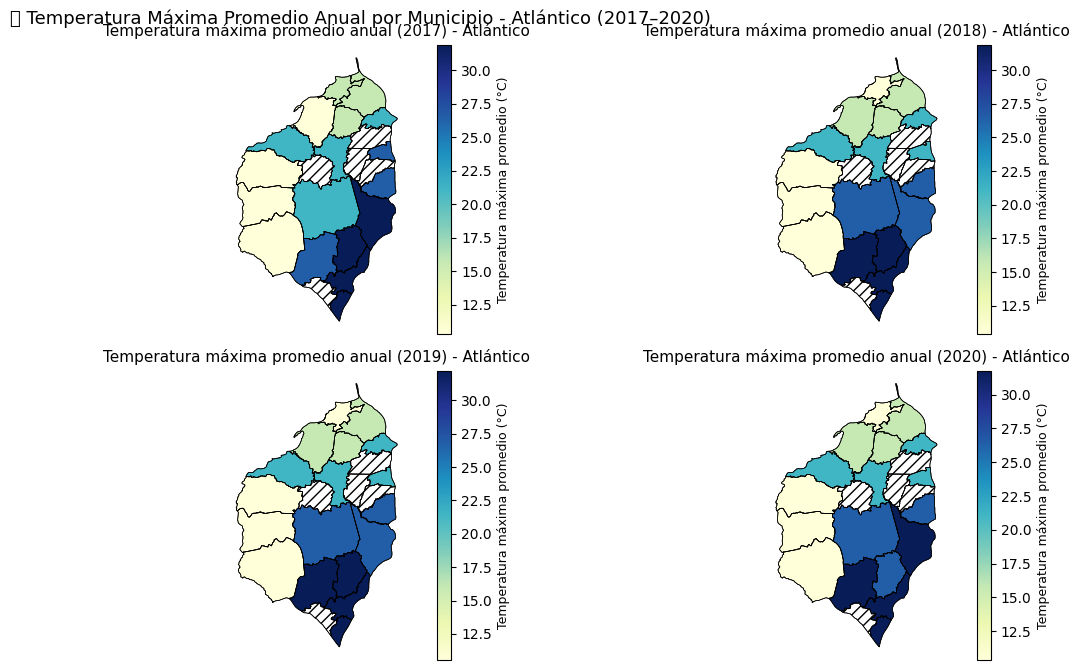

In [16]:
# ------------------------------------------------------------
# 🌡️ Temperatura Máxima Promedio Anual (2017–2020) - Atlántico
# ------------------------------------------------------------
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from rasterstats import zonal_stats
import xarray as xr
import os
import mapclassify

# ------------------------------------------------------------
# 1️⃣ Configuración general
# ------------------------------------------------------------
años = [2017, 2018, 2019, 2020]
base_path = r"C:\Dengue\Datos Clima"
shapefile = r"Mapas/Municipio/MGN_ADM_MPIO_GRAFICO.shp"

# Cargar shapefile del Atlántico
gdf_base = gpd.read_file(shapefile, encoding="utf_8")
gdf_base = gdf_base.rename(columns={'mpio_cnmbr': 'municipio'})
gdf_base = gdf_base[gdf_base['dpto_cnmbr'] == 'ATLÁNTICO']

# ------------------------------------------------------------
# 2️⃣ Crear figura 2x2 y aplanar ejes
# ------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 7))
axes = axes.flatten()  # ✅ para recorrer con un solo índice

# ------------------------------------------------------------
# 3️⃣ Procesar cada año
# ------------------------------------------------------------
for i, año in enumerate(años):
    ruta = fr"{base_path}\temp_max_atl_{año}"

    # Abrir todos los .nc del año y combinarlos
    archivos_nc = [os.path.join(ruta, f) for f in os.listdir(ruta) if f.endswith(".nc")]
    ds = xr.open_mfdataset(archivos_nc, combine="by_coords")

    # Variable de temperatura máxima (convertir de Kelvin a °C)
    var = ds["Temperature_Air_2m_Max_24h"].rio.write_crs("EPSG:4326") - 273.15

    # Promedio anual
    promedio_anual = var.mean(dim="time")

    # Guardar raster temporal
    temp_raster = fr"{base_path}\figs\temp_max_promedio_anual_atl_{año}.tif"
    promedio_anual.rio.to_raster(temp_raster)

    # Copiar shapefile base
    gdf = gdf_base.copy()

    # Calcular promedio por municipio
    stats = zonal_stats(
        gdf,
        temp_raster,
        stats="mean",
        nodata=np.nan
    )
    gdf["temp_max_promedio"] = [s["mean"] for s in stats]

    # --------------------------------------------------------
    # Graficar mapa
    # --------------------------------------------------------
    ax = axes[i]
    cmap = "YlGnBu"

    gdf.boundary.plot(ax=ax, color="black", linewidth=0.5)
    gdf_plot = gdf.plot(
        column="temp_max_promedio",
        cmap=cmap,
        scheme="Quantiles",
        k=5,
        edgecolor="black",
        linewidth=0.5,
        ax=ax,
        missing_kwds={
            "color": "white",
            "edgecolor": "black",
            "hatch": "///",
            "label": "Sin datos"
        }
    )

    # Escala de colores individual
    sm = plt.cm.ScalarMappable(
        cmap=cmap,
        norm=plt.Normalize(
            vmin=gdf["temp_max_promedio"].min(),
            vmax=gdf["temp_max_promedio"].max()
        )
    )
    sm._A = []
    cbar = fig.colorbar(sm, ax=ax, orientation="vertical", fraction=0.036, pad=0.04)
    cbar.set_label("Temperatura máxima promedio (°C)", fontsize=9)

    # Título y estilo
    ax.set_title(f"Temperatura máxima promedio anual ({año}) - Atlántico", fontsize=11)
    ax.axis("off")

# ------------------------------------------------------------
# 4️⃣ Ajuste final
# ------------------------------------------------------------
plt.suptitle("🌡️ Temperatura Máxima Promedio Anual por Municipio - Atlántico (2017–2020)",
             fontsize=13, y=0.95)
plt.tight_layout()
plt.show()


## Minima

In [15]:
ruta = r"C:\Dengue\Datos Clima\temp_min_atl_2017"
archivos = [f for f in os.listdir(ruta) if f.endswith('.nc')]
print(f"Total de archivos: {len(archivos)}")
print(archivos[:5])  # muestra los primeros 5

dsi = xr.open_mfdataset(os.path.join(ruta, "*.nc"), combine="by_coords")

print(dsi)

print(list(dsi.data_vars))

Total de archivos: 365
['Temperature-Air-2m_Min-24h_C3S-glob-agric_AgERA5_20170101_final-v2.0.0.area-subset.11.3.-74.5.10.2.-75.2.nc', 'Temperature-Air-2m_Min-24h_C3S-glob-agric_AgERA5_20170102_final-v2.0.0.area-subset.11.3.-74.5.10.2.-75.2.nc', 'Temperature-Air-2m_Min-24h_C3S-glob-agric_AgERA5_20170103_final-v2.0.0.area-subset.11.3.-74.5.10.2.-75.2.nc', 'Temperature-Air-2m_Min-24h_C3S-glob-agric_AgERA5_20170104_final-v2.0.0.area-subset.11.3.-74.5.10.2.-75.2.nc', 'Temperature-Air-2m_Min-24h_C3S-glob-agric_AgERA5_20170105_final-v2.0.0.area-subset.11.3.-74.5.10.2.-75.2.nc']
<xarray.Dataset> Size: 118kB
Dimensions:                     (time: 365, lat: 11, lon: 7)
Coordinates:
  * time                        (time) datetime64[ns] 3kB 2017-01-01 ... 2017...
  * lat                         (lat) float64 88B 11.2 11.1 11.0 ... 10.3 10.2
  * lon                         (lon) float64 56B -75.1 -75.0 ... -74.6 -74.5
Data variables:
    Temperature_Air_2m_Min_24h  (time, lat, lon) float32 112kB d

C:\Users\TAWTOCA\AppData\Local\Temp\ipykernel_5744\1745898342.py:44: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf["geometry_centroid"] = gdf.geometry.centroid


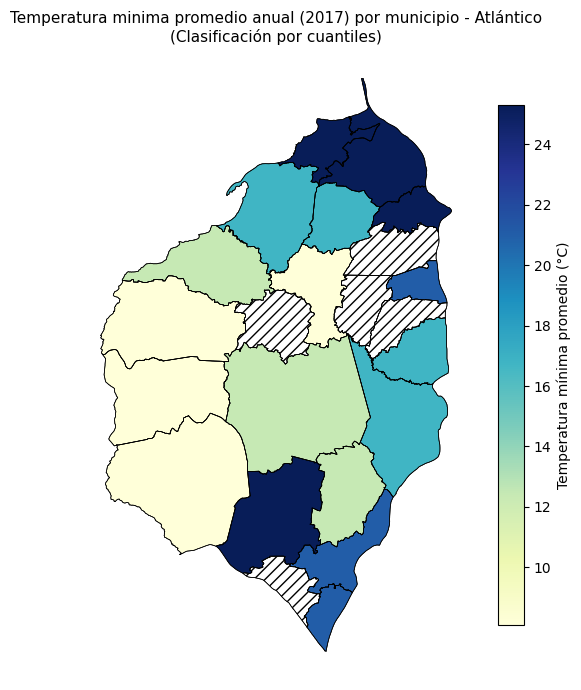

In [ ]:
# ------------------------------------------------------------
# 🌡️ Temperatura Máxima Promedio Anual (2017) - Atlántico
# ------------------------------------------------------------
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from rasterstats import zonal_stats
import mapclassify

# ------------------------------------------------------------
# 1️⃣ Variable principal
# ------------------------------------------------------------
# Convertir de Kelvin a °C si aplica
var = dsi["Temperature_Air_2m_Min_24h"].rio.write_crs("EPSG:4326") - 273.15

# Promedio anual (por píxel)
promedio_anual = var.mean(dim="time")

# ------------------------------------------------------------
# 2️⃣ Shapefile del Atlántico
# ------------------------------------------------------------
gdf = gpd.read_file("Mapas/Municipio/MGN_ADM_MPIO_GRAFICO.shp", encoding="utf_8")
gdf = gdf.rename(columns={'mpio_cnmbr': 'municipio'})
gdf = gdf[gdf['dpto_cnmbr'] == 'ATLÁNTICO']

# ------------------------------------------------------------
# 3️⃣ Guardar raster temporal y calcular promedio por municipio
# ------------------------------------------------------------
temp_raster = r"C:\Dengue\Datos Clima\figs\temp_min_promedio_anual_atl_2017.tif"
promedio_anual.rio.to_raster(temp_raster)

stats = zonal_stats(
    gdf,
    temp_raster,
    stats="mean",
    nodata=np.nan
)

gdf["temp_min_promedio"] = [s["mean"] for s in stats]

# ------------------------------------------------------------
# 4️⃣ Calcular centroides
# ------------------------------------------------------------
gdf["geometry_centroid"] = gdf.geometry.centroid
gdf["lon"] = gdf["geometry_centroid"].x
gdf["lat"] = gdf["geometry_centroid"].y

# ------------------------------------------------------------
# 5️⃣ Graficar mapa final (sin ejes, con escala de colores)
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 7))

# Bordes
gdf.boundary.plot(ax=ax, color="black", linewidth=0.5)

# Mapa principal
cmap = "YlGnBu"
gdf_plot = gdf.plot(
    column="temp_min_promedio",
    cmap=cmap,
    scheme="Quantiles",
    k=5,
    edgecolor="black",
    linewidth=0.5,
    ax=ax,
    missing_kwds={
        "color": "white",
        "edgecolor": "black",
        "hatch": "///",
        "label": "Sin datos"
    }
)

# Escala de colores
sm = plt.cm.ScalarMappable(
    cmap=cmap,
    norm=plt.Normalize(
        vmin=gdf["temp_min_promedio"].min(),
        vmax=gdf["temp_min_promedio"].max()
    )
)
sm._A = []  # necesario para crear la barra
cbar = fig.colorbar(sm, ax=ax, orientation="vertical", fraction=0.036, pad=0.04)
cbar.set_label("Temperatura mínima promedio (°C)", fontsize=10)

# Título
plt.title("Temperatura minima promedio anual (2017) por municipio - Atlántico\n(Clasificación por cuantiles)",
          fontsize=11)

# Ocultar ejes
plt.axis("off")

plt.tight_layout()
plt.show()


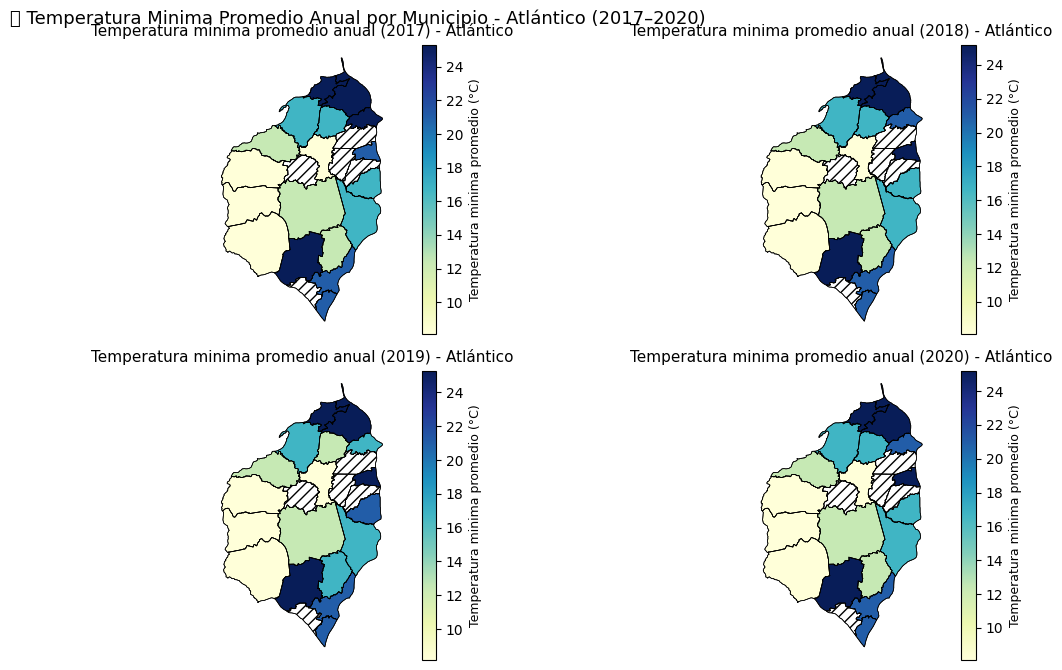

In [17]:
# ------------------------------------------------------------
# 🌡️ Temperatura Máxima Promedio Anual (2017–2020) - Atlántico
# ------------------------------------------------------------
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from rasterstats import zonal_stats
import xarray as xr
import os
import mapclassify

# ------------------------------------------------------------
# 1️⃣ Configuración general
# ------------------------------------------------------------
años = [2017, 2018, 2019, 2020]
base_path = r"C:\Dengue\Datos Clima"
shapefile = r"Mapas/Municipio/MGN_ADM_MPIO_GRAFICO.shp"

# Cargar shapefile del Atlántico
gdf_base = gpd.read_file(shapefile, encoding="utf_8")
gdf_base = gdf_base.rename(columns={'mpio_cnmbr': 'municipio'})
gdf_base = gdf_base[gdf_base['dpto_cnmbr'] == 'ATLÁNTICO']

# ------------------------------------------------------------
# 2️⃣ Crear figura 2x2 y aplanar ejes
# ------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 7))
axes = axes.flatten()  # ✅ para recorrer con un solo índice

# ------------------------------------------------------------
# 3️⃣ Procesar cada año
# ------------------------------------------------------------
for i, año in enumerate(años):
    ruta = fr"{base_path}\temp_min_atl_{año}"

    # Abrir todos los .nc del año y combinarlos
    archivos_nc = [os.path.join(ruta, f) for f in os.listdir(ruta) if f.endswith(".nc")]
    ds = xr.open_mfdataset(archivos_nc, combine="by_coords")

    # Variable de temperatura máxima (convertir de Kelvin a °C)
    var = ds["Temperature_Air_2m_Min_24h"].rio.write_crs("EPSG:4326") - 273.15

    # Promedio anual
    promedio_anual = var.mean(dim="time")

    # Guardar raster temporal
    temp_raster = fr"{base_path}\figs\temp_max_promedio_anual_atl_{año}.tif"
    promedio_anual.rio.to_raster(temp_raster)

    # Copiar shapefile base
    gdf = gdf_base.copy()

    # Calcular promedio por municipio
    stats = zonal_stats(
        gdf,
        temp_raster,
        stats="mean",
        nodata=np.nan
    )
    gdf["temp_min_promedio"] = [s["mean"] for s in stats]

    # --------------------------------------------------------
    # Graficar mapa
    # --------------------------------------------------------
    ax = axes[i]
    cmap = "YlGnBu"

    gdf.boundary.plot(ax=ax, color="black", linewidth=0.5)
    gdf_plot = gdf.plot(
        column="temp_min_promedio",
        cmap=cmap,
        scheme="Quantiles",
        k=5,
        edgecolor="black",
        linewidth=0.5,
        ax=ax,
        missing_kwds={
            "color": "white",
            "edgecolor": "black",
            "hatch": "///",
            "label": "Sin datos"
        }
    )

    # Escala de colores individual
    sm = plt.cm.ScalarMappable(
        cmap=cmap,
        norm=plt.Normalize(
            vmin=gdf["temp_min_promedio"].min(),
            vmax=gdf["temp_min_promedio"].max()
        )
    )
    sm._A = []
    cbar = fig.colorbar(sm, ax=ax, orientation="vertical", fraction=0.036, pad=0.04)
    cbar.set_label("Temperatura minima promedio (°C)", fontsize=9)

    # Título y estilo
    ax.set_title(f"Temperatura minima promedio anual ({año}) - Atlántico", fontsize=11)
    ax.axis("off")

# ------------------------------------------------------------
# 4️⃣ Ajuste final
# ------------------------------------------------------------
plt.suptitle("🌡️ Temperatura Minima Promedio Anual por Municipio - Atlántico (2017–2020)",
             fontsize=13, y=0.95)
plt.tight_layout()
plt.show()
